<a href="https://colab.research.google.com/github/puck-arthur/data-learning/blob/main/notebooks/week4_feature_engineering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Week 4 – Feature Engineering

I'll be using the same data from week 3 to test if I can create new columns using my exploratory analysis and hypothesis created from the data to improve my model performance

1. **Generate Candidate Features**  
   Write a short function or notebook block that creates:  
   - One or two interaction terms
   - One polynomial term (e.g. squared) for a numeric column you suspect might be nonlinear
   - One binned version of a continuous column

2. **Update Pipeline**  
   - Use a FunctionTransformer (from sklearn.preprocessing) to wrap your “create_features(df)” function.
   - In your ColumnTransformer, add a branch for “custom features” that points to that FunctionTransformer.
   - Leave the other branches (numeric, ordinal, nominal) unchanged from Week 3.

3. **Cross‐Validate With/Without New Features**  

4. **Inspect Importance or Coefficients**  
   
5. **Prune if Necessary**  
   - If any new feature has near‐zero importance, drop it and rerun CV.
   - If any raw column has zero coefficient or zero importance, drop it too.

In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("adilshamim8/student-depression-dataset")

print("Path to dataset files:", path)

Path to dataset files: /kaggle/input/student-depression-dataset


In [2]:
import pandas as pd

df_raw = pd.read_csv(path + '/student_depression_dataset.csv')

df_raw.head(20)

,id,Gender,Age,City,Profession,Academic Pressure,Work Pressure,CGPA,Study Satisfaction,Job Satisfaction,Sleep Duration,Dietary Habits,Degree,Have you ever had suicidal thoughts ?,Work/Study Hours,Financial Stress,Family History of Mental Illness,Depression
0,2,Male,33.0,Visakhapatnam,Student,5.0,0.0,8.97,2.0,0.0,'5-6 hours',Healthy,B.Pharm,Yes,3.0,1.0,No,1
1,8,Female,24.0,Bangalore,Student,2.0,0.0,5.90,5.0,0.0,'5-6 hours',Moderate,BSc,No,3.0,2.0,Yes,0
2,26,Male,31.0,Srinagar,Student,3.0,0.0,7.03,5.0,0.0,'Less than 5 hours',Healthy,BA,No,9.0,1.0,Yes,0
3,30,Female,28.0,Varanasi,Student,3.0,0.0,5.59,2.0,0.0,'7-8 hours',Moderate,BCA,Yes,4.0,5.0,Yes,1
4,32,Female,25.0,Jaipur,Student,4.0,0.0,8.13,3.0,0.0,'5-6 hours',Moderate,M.Tech,Yes,1.0,1.0,No,0
5,33,Male,29.0,Pune,Student,2.0,0.0,5.70,3.0,0.0,'Less than 5 hours',Healthy,PhD,No,4.0,1.0,No,0
6,52,Male,30.0,Thane,Student,3.0,0.0,9.54,4.0,0.0,'7-8 hours',Healthy,BSc,No,1.0,2.0,No,0
7,56,Female,30.0,Chennai,Student,2.0,0.0,8.04,4.0,0.0,'Less than 5 hours',Unhealthy,'Class 12',No,0.0,1.0,Yes,0
8,59,Male,28.0,Nagpur,Student,3.0,0.0,9.79,1.0,0.0,'7-8 hours',Moderate,B.Ed,Yes,12.0,3.0,No,1
9,62,Male,31.0,Nashik,Student,2.0,0.0,8.38,3.0,0.0,'Less than 5 hours',Moderate,LLB,Yes,2.0,5.0,No,1


In [34]:
# Leeeets make some EDA

df_raw.info()

<class 'pandas.core.frame.DataFrame'>
Index: 27837 entries, 0 to 27900
Data columns (total 13 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   id                                     27837 non-null  int64  
 1   Gender                                 27837 non-null  object 
 2   Age                                    27837 non-null  int64  
 3   Academic Pressure                      27837 non-null  int64  
 4   CGPA                                   27837 non-null  float64
 5   Study Satisfaction                     27837 non-null  int64  
 6   Sleep Duration                         27837 non-null  object 
 7   Dietary Habits                         27837 non-null  object 
 8   Have you ever had suicidal thoughts ?  27837 non-null  object 
 9   Work/Study Hours                       27837 non-null  int64  
 10  Financial Stress                       27837 non-null  int64  
 11  Family 

In [5]:
df_raw['Age'] = df_raw['Age'].astype('int')

for column in selected_columns:
  df_raw[column] = df_raw[column].astype('int')

In [8]:
df_raw = df_raw.drop(columns=['Job Satisfaction', 'Work Pressure'])

In [13]:
df_raw['Sleep Duration'] = df_raw['Sleep Duration'].str.replace("""'""", '')

In [14]:
# Most of the data is about Students, but some of them arent. I will remove them, since the data is about students
df_raw = df_raw[df_raw['Profession'] == 'Student']

# I will drop the Others sleep duration values too, since they are trash
df_raw = df_raw[df_raw['Sleep Duration'] != 'Others']

# Others dietary habits too
df_raw = df_raw[df_raw['Dietary Habits'] != 'Others']

# ? Financial stress too
df_raw = df_raw[df_raw['Financial Stress'] != '?']

# Also, financial stress should be a int column
df_raw['Financial Stress'] = df_raw['Financial Stress'].astype('float').astype('int') # Since the number is like 1.0 it can't go directly to int

# Some columns dont seem relevant, so I will remove them from the dataset
df_raw = df_raw.drop(columns=['City', 'Degree', 'Profession'])

df = df_raw.copy()

In [15]:
df.describe(include='all')

,id,Gender,Age,Academic Pressure,CGPA,Study Satisfaction,Sleep Duration,Dietary Habits,Have you ever had suicidal thoughts ?,Work/Study Hours,Financial Stress,Family History of Mental Illness,Depression
count,27837.000000,27837,27837.000000,27837.000000,27837.000000,27837.000000,27837,27837,27837,27837.000000,27837.000000,27837,27837.000000
unique,NaN,2,NaN,NaN,NaN,NaN,4,3,2,NaN,NaN,2,NaN
top,NaN,Male,NaN,NaN,NaN,NaN,Less than 5 hours,Unhealthy,Yes,NaN,NaN,No,NaN
freq,NaN,15511,NaN,NaN,NaN,NaN,8297,10300,17610,NaN,NaN,14364,NaN
mean,70447.556597,NaN,25.819772,3.140748,7.656175,2.943385,NaN,NaN,NaN,7.158889,3.139814,NaN,0.585192
std,40639.277239,NaN,4.906603,1.381791,1.470791,1.361073,NaN,NaN,NaN,3.706690,1.437217,NaN,0.492698
min,2.000000,NaN,18.000000,0.000000,0.000000,0.000000,NaN,NaN,NaN,0.000000,1.000000,NaN,0.000000
25%,35065.000000,NaN,21.000000,2.000000,6.290000,2.000000,NaN,NaN,NaN,4.000000,2.000000,NaN,0.000000
50%,70684.000000,NaN,25.000000,3.000000,7.770000,3.000000,NaN,NaN,NaN,8.000000,3.000000,NaN,1.000000
75%,105828.000000,NaN,30.000000,4.000000,8.920000,4.000000,NaN,NaN,NaN,10.000000,4.000000,NaN,1.000000


In [16]:
df = df.drop(columns='id')

In [17]:
renaming_dict = {
    'Gender': 'gender',
    'Age': 'age',
    'Academic Pressure': 'academic_pressure',
    'CGPA': 'cgpa',
    'Study Satisfaction': 'study_satisfaction',
    'Sleep Duration': 'sleep_duration',
    'Dietary Habits': 'dietary_habits',
    'Have you ever had suicidal thoughts ?': 'suicidal_thoughts',
    'Work/Study Hours': 'work_study_hours',
    'Financial Stress': 'financial_stress',
    'Family History of Mental Illness': 'family_history_mental_illness',
    'Depression': 'depression'
}

df = df.rename(columns=renaming_dict)

In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 27837 entries, 0 to 27900
Data columns (total 12 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   gender                         27837 non-null  object 
 1   age                            27837 non-null  int64  
 2   academic_pressure              27837 non-null  int64  
 3   cgpa                           27837 non-null  float64
 4   study_satisfaction             27837 non-null  int64  
 5   sleep_duration                 27837 non-null  object 
 6   dietary_habits                 27837 non-null  object 
 7   suicidal_thoughts              27837 non-null  object 
 8   work_study_hours               27837 non-null  int64  
 9   financial_stress               27837 non-null  int64  
 10  family_history_mental_illness  27837 non-null  object 
 11  depression                     27837 non-null  int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 2.

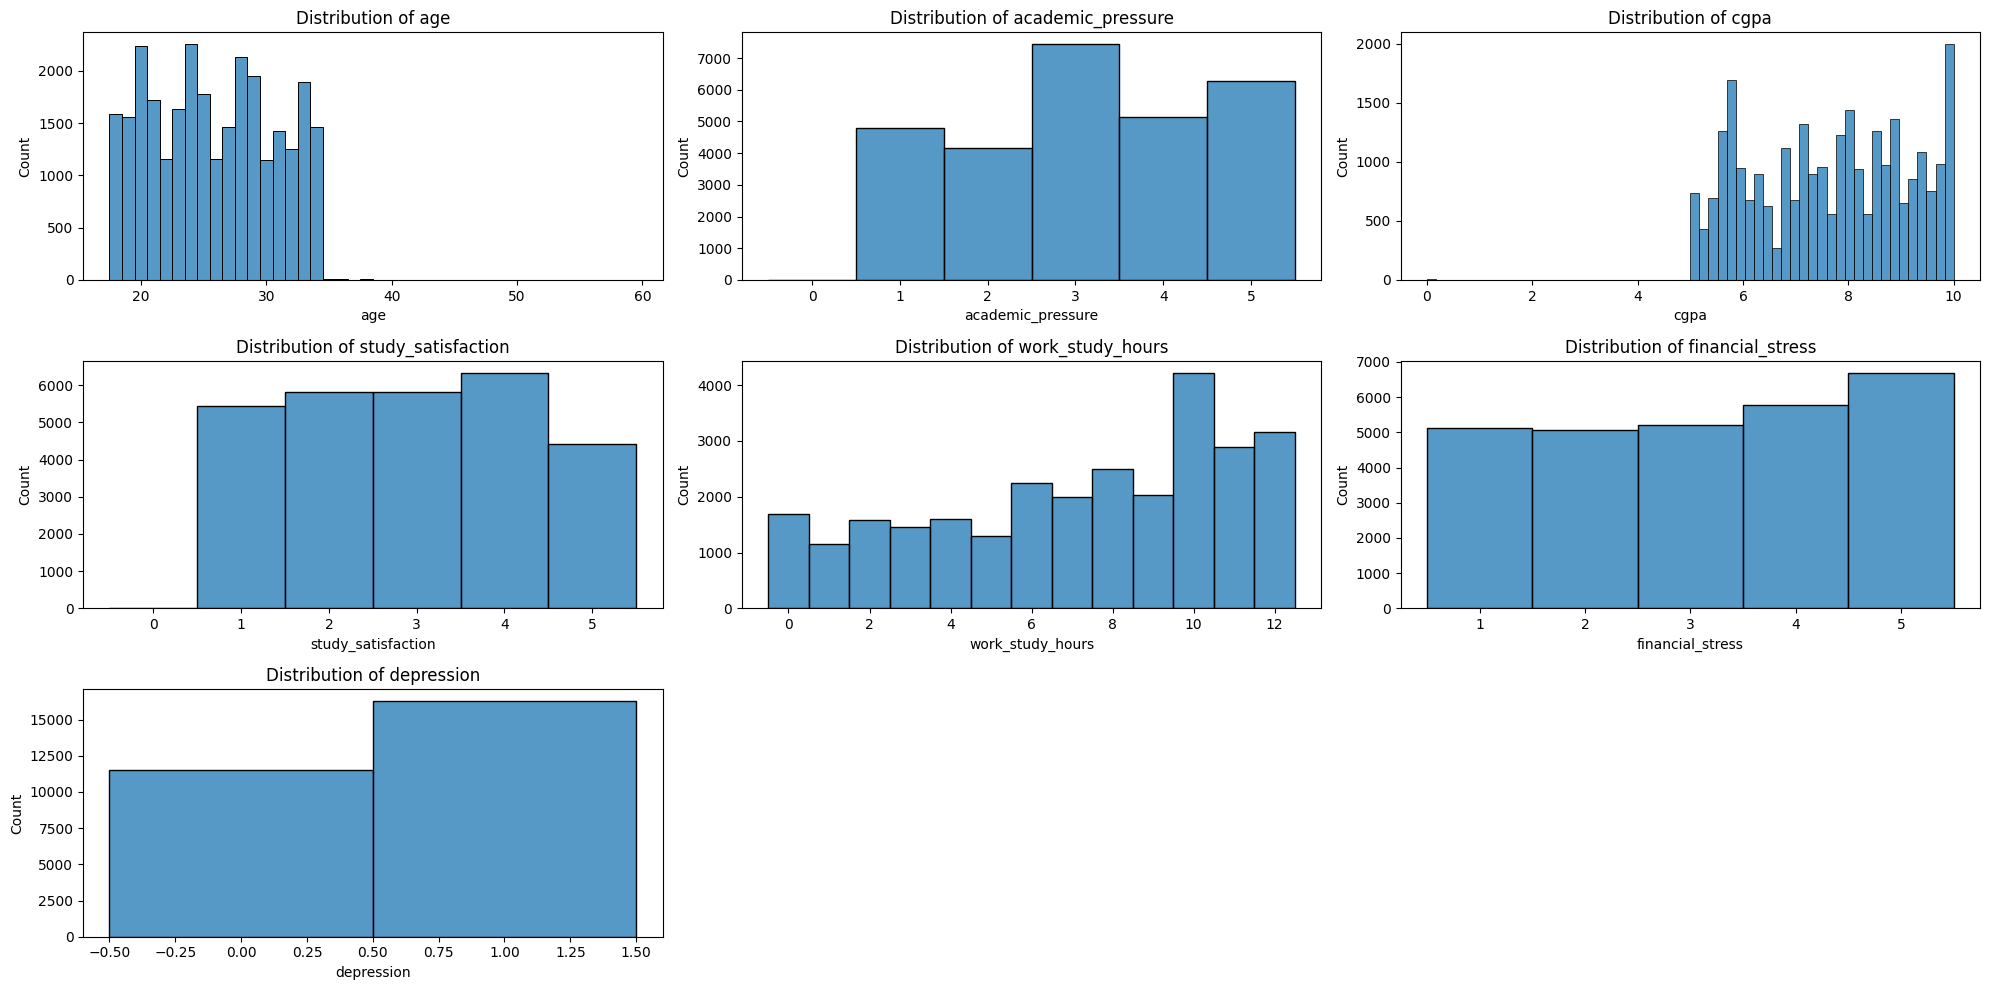

In [19]:
import matplotlib.pyplot as plt
import seaborn as sb
import math

# Code to visualize the histogram of all numerical values in the dataframe

numeric_columns = list(df.select_dtypes(include='number').dtypes.items()) # Tupples in the format (column_name, dtype)

# sample = df.sample(frac=0.8, random_state=0)  # for large datasets

num_columns = 3
num_rows = math.ceil(len(numeric_columns) / num_columns)

plt.figure(figsize=(20, 10))

i = 0

for column_name, dtype in numeric_columns:

  # Checking if the histogram should be discrete
  n_uniques = df[column_name].nunique()
  discrete = ((dtype == 'int64') & (n_uniques < 50)) # if is integer with fewer than 50 values, discrete==True

  # Plotting
  plt.subplot(num_rows, num_columns, i + 1)
  sb.histplot(
      data=df, # Choose dataframe here
      x=column_name,
      #kde=True, #Only if data is small
      discrete=discrete
  )
  plt.title(f'Distribution of {column_name}')
  i+=1 # go to next item in the subplot

plt.tight_layout()
plt.show()

In [20]:
# Lets split the data

from sklearn.model_selection import train_test_split

X = df.drop(columns='depression')
y = df['depression']

X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.8, random_state=42)

In [21]:
# Lets check a baseline accuracy for our dataset

from sklearn.dummy import DummyClassifier

dummy = DummyClassifier(strategy="most_frequent")
dummy.fit(X_train, y_train)
print("Baseline accuracy:", dummy.score(X_test, y_test))

Baseline accuracy: 0.5817169540229885


In [22]:
# Lets create our preprocessing pipeline

# Lets change all string columns to one of these: Binary, Nominal, Ordinal with sklearn

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

# Binary
binary_cols = ['suicidal_thoughts', 'family_history_mental_illness']

# Nominal
nominal_cols = ['gender']

# Ordinal
ordinal_cols = ['sleep_duration', 'dietary_habits']

ordinal_categories = [
    ['Less than 5 hours', '5-6 hours', '7-8 hours', 'More than 8 hours'],
    ['Unhealthy', 'Moderate', 'Healthy']
]

# Now we make a pipeline for each type of category
binary_pipeline = Pipeline([
    ('binary', OrdinalEncoder(categories=[['No', 'Yes'], ['No', 'Yes']]))
])

nominal_pipeline = Pipeline([
    ('nominal', OneHotEncoder(drop='first'))
])

ordinal_pipeline = Pipeline([
    ('ordinal', OrdinalEncoder(categories=ordinal_categories))
])

# Lets create a scaler too
numerical_cols = df.drop(columns='depression').select_dtypes(include='number').columns.to_list()
numerical_pipeline = Pipeline([
    ('scaler', StandardScaler())
])

# Now we join the categories pipelines and scaler in a single ColumnTransformer object
preprocessing = ColumnTransformer([
    ('bin', binary_pipeline, binary_cols),
    ('nom', nominal_pipeline, nominal_cols),
    ('ord', ordinal_pipeline, ordinal_cols),
    ('num', numerical_pipeline, numerical_cols)
])

Accuracy: 0.8482399425287356
Precision: 0.8573134328358208
Recall: 0.8866934238962643
F1: 0.8717559568978601


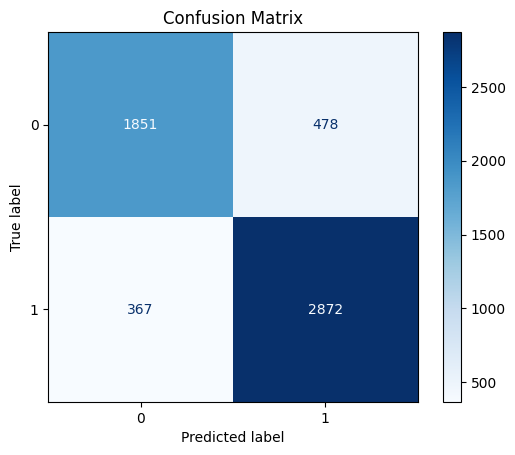

In [35]:
# Lets check how well our model did (On week 3 we found out that Logistic Tree was the best model, so lets keep using that one)
from sklearn.linear_model import LogisticRegression

# Now we create the final pipeline that does the preprocessing and also runs the model
model_pipe = Pipeline([
    ('pre', preprocessing),
    ('model', LogisticRegression())
])

# Lets run the model
model_pipe.fit(X_train, y_train)

# Predict the outcome
y_pred = model_pipe.predict(X_test)

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1    = f1_score(y_test, y_pred)

print("Accuracy:", acc)
print("Precision:", prec)
print("Recall:", recall)
print("F1:", f1)

# Now lets plot a confusion matrix

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Blues")
plt.title("Confusion Matrix")
plt.show()

# Save the performance metrics on a list for later use
logistic_regression_baseline_list = ['baseline', acc, prec, recall, f1]

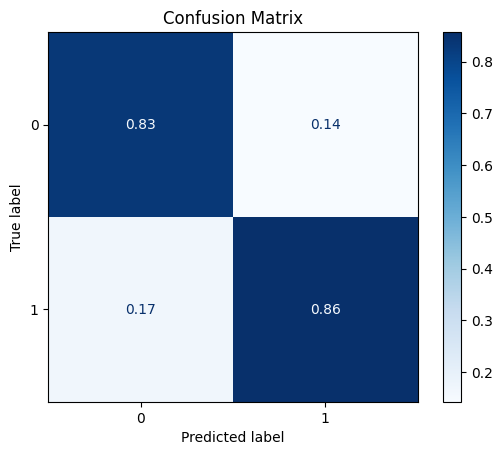

In [36]:
# Plot normalized confusion matrix to see values as percentages
cm = confusion_matrix(y_test, y_pred, normalize='pred')
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Blues")
plt.title("Confusion Matrix")
plt.show()

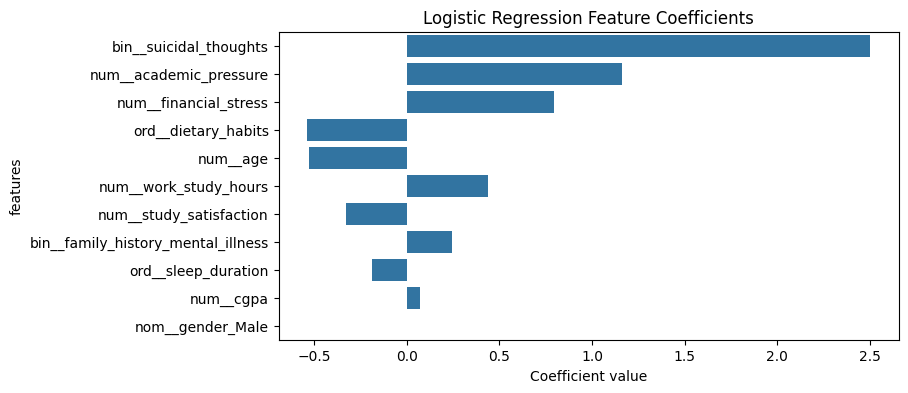

In [30]:
# Lets check feature importance (actually for logistic models it is a coefficient bar chart) for our chosen model

# the preprocessing step
pre = model_pipe.named_steps['pre']

# this method exists in scikit-learn ≥1.0
feature_names = pre.get_feature_names_out()

# final classifier step
clf = model_pipe.named_steps['model']

# shape = (1, n_features)
coefs = clf.coef_[0]

# Creating a dataframe with the extracted data
df_features = pd.DataFrame({'features': feature_names, 'coefficients': coefs})

# Ordering by absolute coefficients for plot
df_features['coefficients_abs'] = abs(df_features['coefficients'])
order = df_features.sort_values('coefficients_abs', ascending=False)['features']

# Plotting
plt.figure(figsize=(8,4))
sb.barplot(
    data=df_features,
    x='coefficients',
    y='features',
    order=order
)
plt.xlabel('Coefficient value')
plt.title('Logistic Regression Feature Coefficients')
plt.show()

## Lets feature engineer some new columns to use on our model to see if we can get better results



<Axes: xlabel='depression', ylabel='cgpa'>

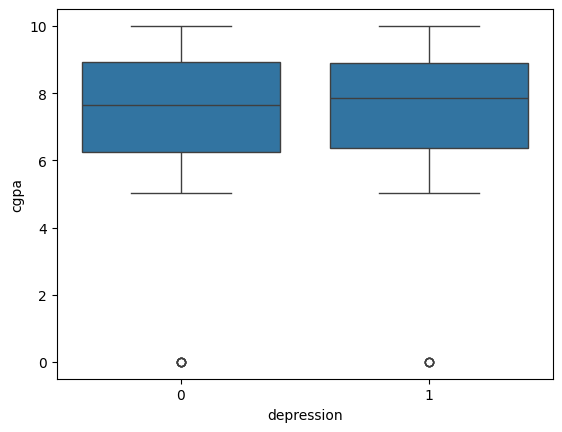

In [38]:
sb.boxplot(
    data=df,
    x='depression',
    y='cgpa'
)

# This metric seems to have no correlation whatsoever

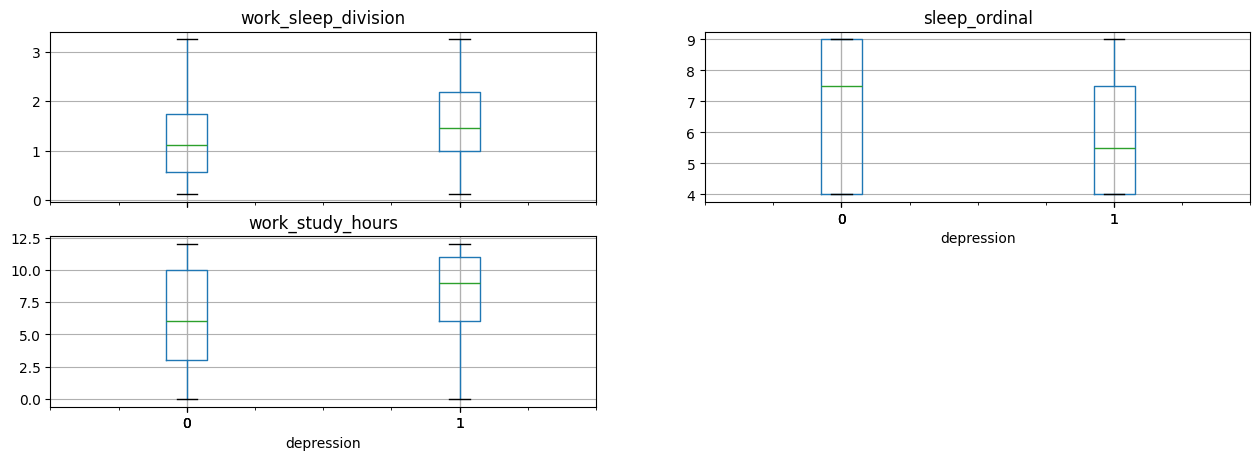

In [49]:
# Lets try to mix sleep and work/study hours on a new column

df_engineering_testing = df.copy()

sleep_map = {
    'Less than 5 hours': 4,
    '5-6 hours': 5.5,
    '7-8 hours': 7.5,
    'More than 8 hours': 9
    }

df_engineering_testing['sleep_ordinal'] = df_engineering_testing['sleep_duration'].map(sleep_map)

df_engineering_testing['work_sleep_division'] = (df_engineering_testing['work_study_hours'] + 1) / df_engineering_testing['sleep_ordinal']

df_engineering_testing.boxplot(
    column=["work_sleep_division", "sleep_ordinal", "work_study_hours"],
    by="depression",
    figsize=(15, 5),
    sharey=False
)
plt.suptitle("")   # (optional) this removes “Boxplot grouped by depression” text
plt.show()

# I will use this new metric

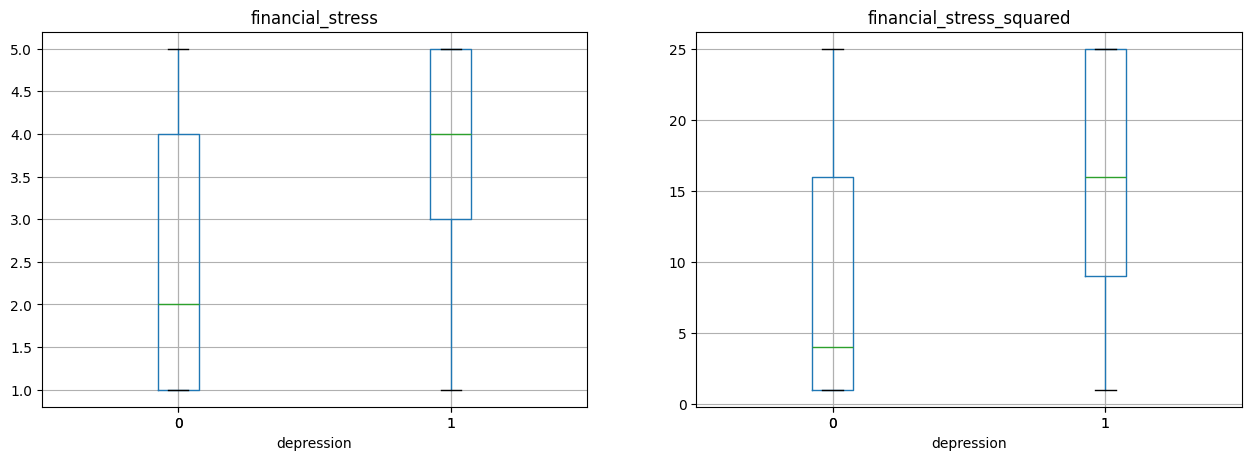

In [53]:
df_engineering_testing['financial_stress_squared'] = df_engineering_testing['financial_stress'] ** 2

df_engineering_testing.boxplot(
    column=["financial_stress", "financial_stress_squared"],
    by="depression",
    figsize=(15, 5),
    sharey=False
)
plt.suptitle("")   # (optional) this removes “Boxplot grouped by depression” text
plt.show()

# I will try this feature

<Axes: xlabel='depression', ylabel='age'>

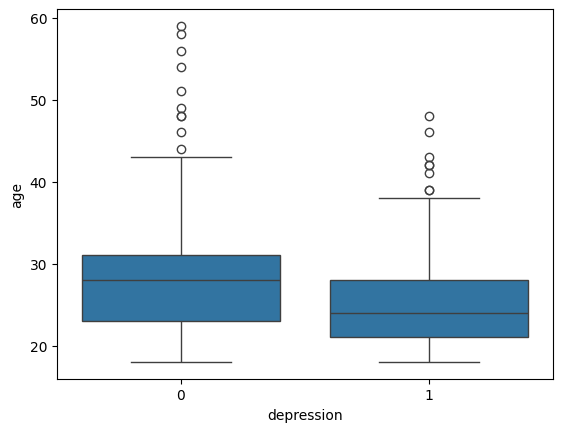

In [37]:
sb.boxplot(
    data=df,
    x='depression',
    y='age'
)

# Maybe I could cluster the age? It seems like a higher age means less depression

In [72]:
bins=[0, 22, 26, 29, 32, 120]
labels=[1, 2, 3, 4, 5]

df_engineering_testing['age_group'] = pd.cut(
    df_engineering_testing['age'],
    bins=bins,
    labels=labels,
    right=True,
    include_lowest=True
)

for label in range(1, 6):
   count_depression = df_engineering_testing[df_engineering_testing['age_group'] == label]['depression'].sum()
   count_total = len(df_engineering_testing[df_engineering_testing['age_group'] == label])
   depression_proportion = count_depression / count_total
   print("Label", label, ":", depression_proportion)

,gender,age,academic_pressure,cgpa,study_satisfaction,sleep_duration,dietary_habits,suicidal_thoughts,work_study_hours,financial_stress,family_history_mental_illness,depression,sleep_ordinal,work_sleep_division,financial_stress_squared,age_group
0,Male,33,5,8.97,2,5-6 hours,Healthy,Yes,3,1,No,1,5.5,0.727273,1,5
1,Female,24,2,5.90,5,5-6 hours,Moderate,No,3,2,Yes,0,5.5,0.727273,4,2
2,Male,31,3,7.03,5,Less than 5 hours,Healthy,No,9,1,Yes,0,4.0,2.500000,1,4
3,Female,28,3,5.59,2,7-8 hours,Moderate,Yes,4,5,Yes,1,7.5,0.666667,25,3
4,Female,25,4,8.13,3,5-6 hours,Moderate,Yes,1,1,No,0,5.5,0.363636,1,2


In [81]:
# I will add the created columns back to the main dataframe and try the regression once again to check for the new results

df['work_sleep_division'] = df_engineering_testing['work_sleep_division']

df['financial_stress_squared'] = df_engineering_testing['financial_stress_squared']

df['age_group'] = pd.to_numeric(df_engineering_testing['age_group'])

Accuracy: 0.8484195402298851
Precision: 0.8577830893337317
Recall: 0.8863846866316765
F1: 0.871849377467355


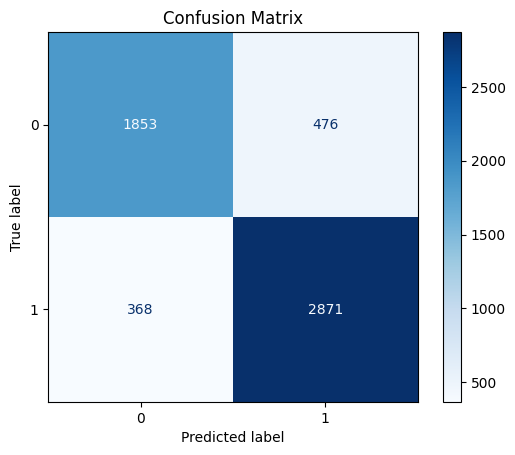

In [83]:
# Lets create our preprocessing pipeline with the new columns

# Lets split the data

X = df.drop(columns='depression')
y = df['depression']

X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.8, random_state=42)

# Lets change all string columns to one of these: Binary, Nominal, Ordinal with sklearn

# Binary
binary_cols = ['suicidal_thoughts', 'family_history_mental_illness']

# Nominal
nominal_cols = ['gender']

# Ordinal
ordinal_cols = ['sleep_duration', 'dietary_habits']

ordinal_categories = [
    ['Less than 5 hours', '5-6 hours', '7-8 hours', 'More than 8 hours'],
    ['Unhealthy', 'Moderate', 'Healthy']
]

# Now we make a pipeline for each type of category
binary_pipeline = Pipeline([
    ('binary', OrdinalEncoder(categories=[['No', 'Yes'], ['No', 'Yes']]))
])

nominal_pipeline = Pipeline([
    ('nominal', OneHotEncoder(drop='first'))
])

ordinal_pipeline = Pipeline([
    ('ordinal', OrdinalEncoder(categories=ordinal_categories))
])

# Lets create a scaler too
numerical_cols = df.drop(columns='depression').select_dtypes(include='number').columns.to_list()
numerical_pipeline = Pipeline([
    ('scaler', StandardScaler())
])

# Now we join the categories pipelines and scaler in a single ColumnTransformer object
preprocessing = ColumnTransformer([
    ('bin', binary_pipeline, binary_cols),
    ('nom', nominal_pipeline, nominal_cols),
    ('ord', ordinal_pipeline, ordinal_cols),
    ('num', numerical_pipeline, numerical_cols)
])

# Now we create the final pipeline that does the preprocessing and also runs the model
model_pipe = Pipeline([
    ('pre', preprocessing),
    ('model', LogisticRegression())
])

# Lets run the model
model_pipe.fit(X_train, y_train)

# Predict the outcome
y_pred = model_pipe.predict(X_test)

acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1    = f1_score(y_test, y_pred)

print("Accuracy:", acc)
print("Precision:", prec)
print("Recall:", recall)
print("F1:", f1)

# Now lets plot a confusion matrix

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Blues")
plt.title("Confusion Matrix")
plt.show()

# Save the performance metrics on a list for later use
logistic_regression_baseline_list = ['engineered', acc, prec, recall, f1]

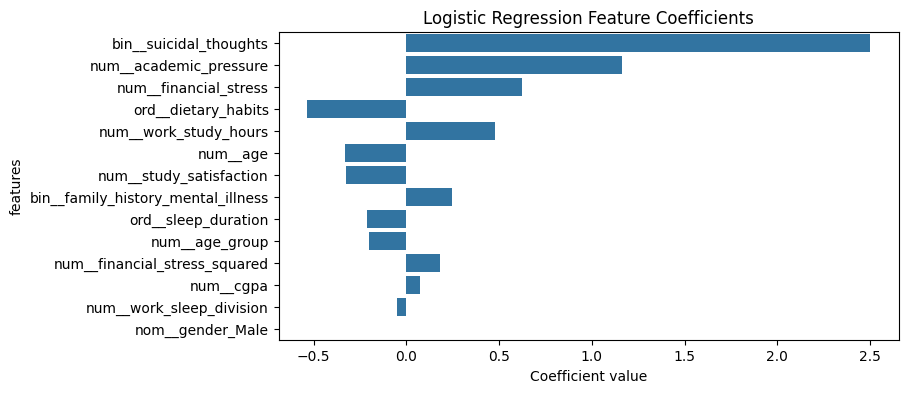

In [84]:
# Lets check feature importance once again to see how the new columns affected the model

# the preprocessing step
pre = model_pipe.named_steps['pre']

# this method exists in scikit-learn ≥1.0
feature_names = pre.get_feature_names_out()

# final classifier step
clf = model_pipe.named_steps['model']

# shape = (1, n_features)
coefs = clf.coef_[0]

# Creating a dataframe with the extracted data
df_features = pd.DataFrame({'features': feature_names, 'coefficients': coefs})

# Ordering by absolute coefficients for plot
df_features['coefficients_abs'] = abs(df_features['coefficients'])
order = df_features.sort_values('coefficients_abs', ascending=False)['features']

# Plotting
plt.figure(figsize=(8,4))
sb.barplot(
    data=df_features,
    x='coefficients',
    y='features',
    order=order
)
plt.xlabel('Coefficient value')
plt.title('Logistic Regression Feature Coefficients')
plt.show()

It seems like the new columns we created were not helpful for the model prediction. That is a bummer.